## Generate some mock data

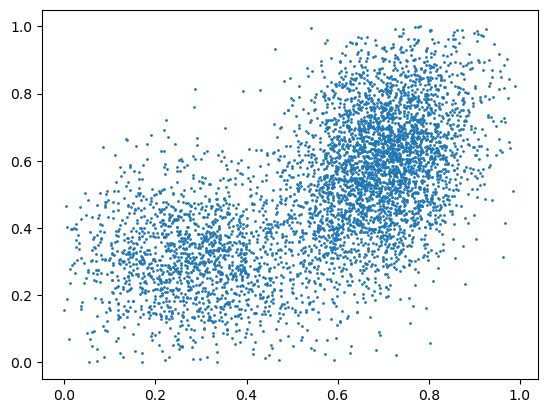

In [2]:
from matplotlib import pyplot as plt
from generate_mock_data import sample_poisson_process, mixture_density

components = [
    {"mean": [0.3, 0.3], "cov": [[0.02, 0.0], [0.0, 0.02]], "weight": 1.0},
    {"mean": [0.7, 0.6], "cov": [[0.01, 0.005], [0.005, 0.03]], "weight": 2.0},
]
points = sample_poisson_process(components, total_intensity=5000, bounds=[(0, 1), (0, 1)], seed=1)
plt.scatter(points[:,0], points[:,1], s=1);

## Adaptive kd-tree triangulation

#### This is sort of meant as an initialization of the triangulation

In [3]:
import sys
sys.path.insert(0, ".")
from triangulation import AdaptiveKDMesh

bounds = [(-0.1, 1.1), (-0.1, 1.1)] # A bit of buffer
mesh = AdaptiveKDMesh(points, bounds)

# Refine until every leaf cell contains <= 50 points.
# (triangle_counts() cannot converge as a loop condition: Delaunay triangles
# span multiple leaf cells and will always accumulate more than leaf_counts.)
while mesh.leaf_counts().max() > 50:
    print(f'Ntriangles = {len(mesh.leaves())}, leaf counts = {mesh.leaf_counts().min()}--{mesh.leaf_counts().max()}')
    mesh.refine(max_count=50)

counts = mesh.triangle_counts()
print(f"Leaves: {len(mesh.leaves())}, Nodes: {len(mesh.nodes)}, Triangles: {len(mesh.triangulation.simplices)}")
print(f"Leaf counts   — min: {mesh.leaf_counts().min()}, max: {mesh.leaf_counts().max()}, mean: {mesh.leaf_counts().mean():.1f}")
print(f"Triangle counts — min: {counts.min()}, max: {counts.max()}, mean: {counts.mean():.1f}")

Ntriangles = 1, leaf counts = 5002--5002
Ntriangles = 2, leaf counts = 2501--2501
Ntriangles = 4, leaf counts = 1250--1251
Ntriangles = 8, leaf counts = 625--626
Ntriangles = 16, leaf counts = 312--313
Ntriangles = 32, leaf counts = 156--157
Ntriangles = 64, leaf counts = 78--79
Leaves: 128, Nodes: 132, Triangles: 258
Leaf counts   — min: 39, max: 40, mean: 39.1
Triangle counts — min: 2, max: 36, mean: 19.4


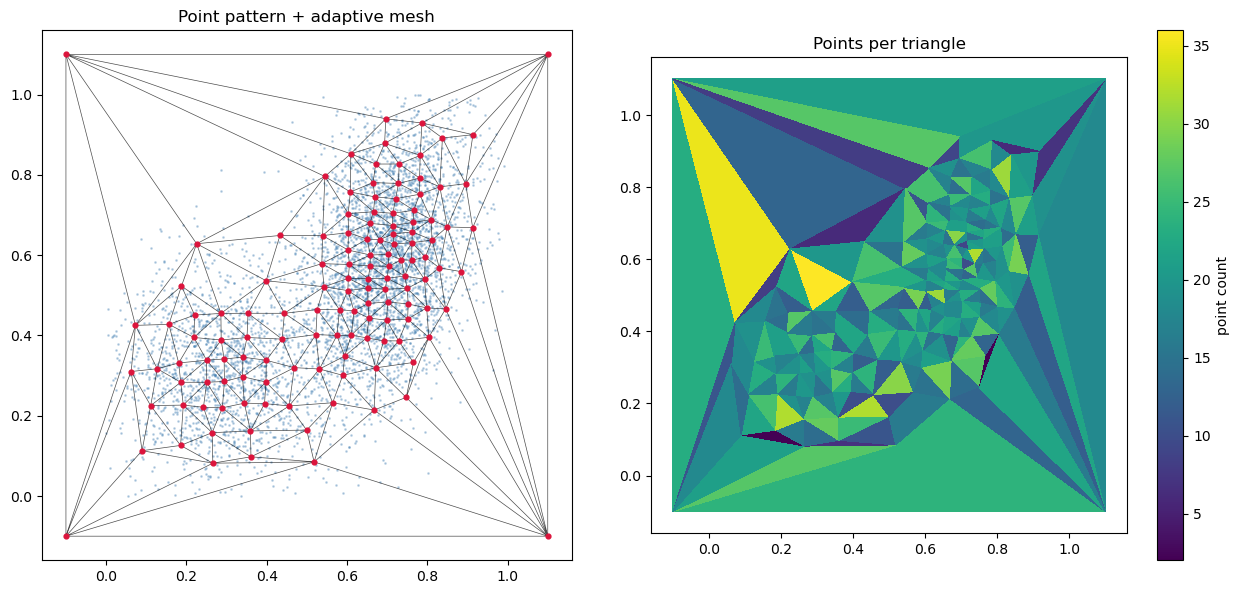

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))

tri = mesh.triangulation

# Left: scatter + mesh
axes[0].scatter(points[:, 0], points[:, 1], s=1, alpha=0.3, color="steelblue")
axes[0].triplot(tri.points[:, 0], tri.points[:, 1], tri.simplices, color="k", lw=0.5, alpha=0.7)
axes[0].scatter(mesh.nodes[:, 0], mesh.nodes[:, 1], s=12, color="crimson", zorder=3)
axes[0].set_aspect("equal")
axes[0].set_title("Point pattern + adaptive mesh")

# Right: per-triangle count as a heatmap
counts = mesh.triangle_counts()
tpc = axes[1].tripcolor(
    tri.points[:, 0], tri.points[:, 1], tri.simplices,
    facecolors=counts, cmap="viridis"
)
plt.colorbar(tpc, ax=axes[1], label="point count")
axes[1].set_aspect("equal")
axes[1].set_title("Points per triangle")

plt.tight_layout()
plt.show()

## SPDE prior using Lindgren, Rue and Lindstroem (LRL) method

In [5]:
import numpy as np
import scipy.linalg as la
from triangulation import assemble_fem_matrices, precision_matrix

kappa = 6.0   # inverse range: larger -> shorter correlation length
alpha = 2     # smoothness order: nu = alpha - d/2 = 1 for d=2

C, G = assemble_fem_matrices(mesh.nodes, mesh.triangulation.simplices)
K, Q = precision_matrix(C, G, kappa=kappa, alpha=alpha)

Q_dense = Q.toarray()
Q_dense += 1e-10 * np.eye(len(Q_dense))  # jitter for numerical safety
L = la.cholesky(Q_dense, lower=True)      # Q = L L^T

def sample_prior(n_samples=1, seed=None):
    """Draw n_samples from N(0, Q^{-1}) by solving L^T x = z, z ~ N(0,I)."""
    rng = np.random.default_rng(seed)
    z = rng.standard_normal((len(L), n_samples))
    return la.solve_triangular(L.T, z, lower=False)  # shape (n_nodes, n_samples)

samples = sample_prior(n_samples=4, seed=0)
print(f"Sample shape: {samples.shape}")
print(f"Sample std (should be ~1 for white noise prior): {samples.std(axis=0).round(3)}")

Sample shape: (132, 4)
Sample std (should be ~1 for white noise prior): [0.032 0.036 0.05  0.038]


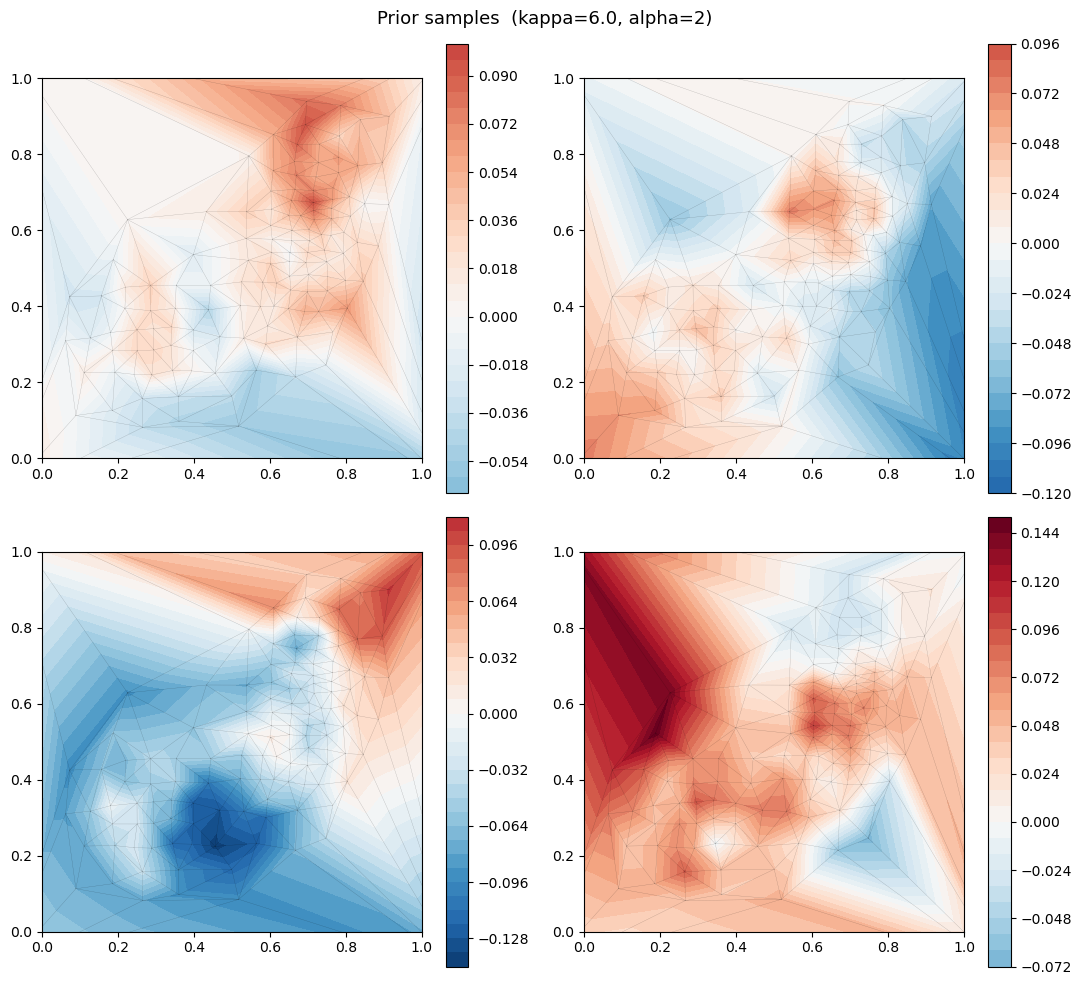

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
nodes = mesh.nodes
simplices = mesh.triangulation.simplices

vmax = np.abs(samples).max()

for ax, s in zip(axes.ravel(), samples.T):
    tcf = ax.tricontourf(
        nodes[:, 0], nodes[:, 1], simplices, s,
        levels=30, cmap="RdBu_r", vmin=-vmax, vmax=vmax
    )
    ax.triplot(nodes[:, 0], nodes[:, 1], simplices, color="k", lw=0.2, alpha=0.3)
    ax.set(xlim=(0,1), ylim=(0,1), aspect="equal")
    plt.colorbar(tcf, ax=ax)

fig.suptitle(f"Prior samples  (kappa={kappa}, alpha={alpha})", fontsize=13)
plt.tight_layout()
plt.show()

## Posterior inference via NUTS (BlackJAX)

In [7]:
from inference import make_log_posterior, run_nuts, predict_intensity

log_post, meta = make_log_posterior(
    Q, mesh.nodes, mesh.triangulation.simplices, mesh.triangulation, points,
    obs_bounds = [(0, 1), (0, 1)],   # restrict integral to data domain, not mesh buffer
)

samples, info = run_nuts(
    log_post, meta,
    n_nodes             = len(mesh.nodes),
    num_warmup          = 1000,
    num_samples         = 1000,
    thinning            = 10,
    seed                = 0,
    progress_bar_kwargs = {"tqdm_type": "std", "print_rate": 10},
)

# Sanity check: posterior mean of total integrated intensity should equal n_obs.
# This holds by the Gamma posterior argument (flat prior on mu + Poisson likelihood).
c = meta["c_lumped"]
N_samples = (np.exp(np.array(samples["x"]) + np.array(samples["mu"])[:, None]) * c).sum(axis=1)
mesh_area = meta["areas"].sum()
print(f"E[N_obs] = {N_samples.mean():.1f}  (should equal n_obs = {meta['n_obs']})")
print(f"Obs-domain area = {meta['domain_area']:.3f},  mesh area = {mesh_area:.3f}")


Running 1000 warmup steps...
  step_size = 0.0892


Sampling: 100%|██████████| 1000/1000 [00:11<00:00, 89.24it/s]


  acceptance rate = 0.86,  divergences = 0
E[N_obs] = 5002.5  (should equal n_obs = 5002)
Obs-domain area = 0.980,  mesh area = 1.440


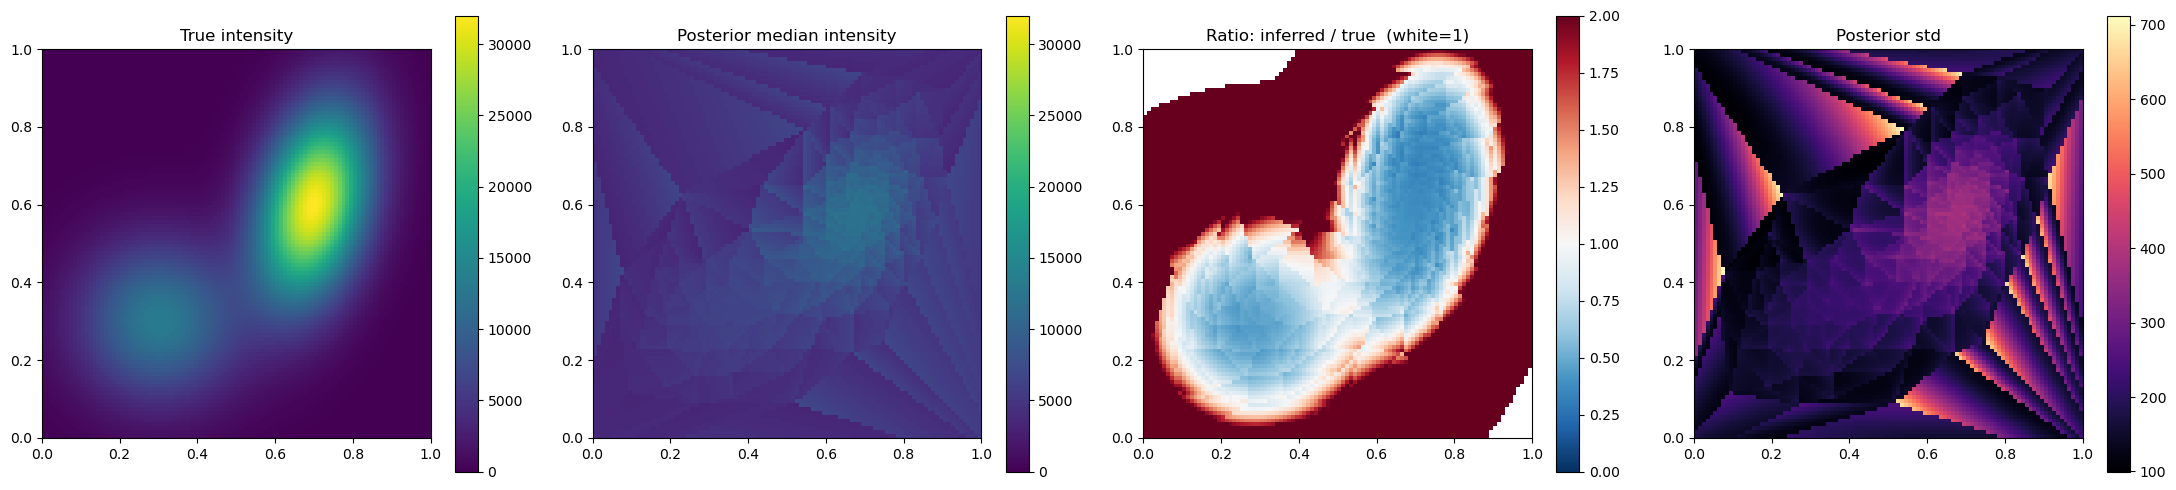

In [8]:
import numpy as np

grid_1d = np.linspace(0, 1, 100)
gx, gy  = np.meshgrid(grid_1d, grid_1d)
grid    = np.column_stack([gx.ravel(), gy.ravel()])

lam           = predict_intensity(samples, mesh.nodes, mesh.triangulation, grid)
median_lam    = np.median(lam, axis=0)
std_lam       = np.std(lam, axis=0)
median_lam_2d = median_lam.reshape(100, 100)
std_lam_2d    = std_lam.reshape(100, 100)

# True intensity: mixture_density integrates to ~1 over R², so multiply by n_obs
# to get the Poisson intensity (expected count per unit area).
true_lam    = mixture_density(grid, components) * meta["n_obs"]
true_lam_2d = true_lam.reshape(100, 100)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
kw = dict(origin="lower", extent=[0, 1, 0, 1], aspect="equal")

vmax = max(true_lam_2d.max(), median_lam_2d.max())

im0 = axes[0].imshow(true_lam_2d,   cmap="viridis", vmin=0, vmax=vmax, **kw)
axes[0].set_title("True intensity")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(median_lam_2d, cmap="viridis", vmin=0, vmax=vmax, **kw)
axes[1].set_title("Posterior median intensity")
plt.colorbar(im1, ax=axes[1])

# Ratio inferred/true: 1 = perfect, <1 = underestimate, >1 = overestimate.
# RdBu_r with vmin=0, vmax=2 centers white at ratio=1.
safe_true = np.where(true_lam_2d > 1.0, true_lam_2d, np.nan)
ratio     = median_lam_2d / safe_true
im2 = axes[2].imshow(ratio, cmap="RdBu_r", vmin=0, vmax=2, **kw)
axes[2].set_title("Ratio: inferred / true  (white=1)")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(std_lam_2d, cmap="magma", **kw)
axes[3].set_title("Posterior std")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()


## Joint inference of field + kappa hyperparameter

In [9]:
from inference import make_log_posterior_with_hyperparams, run_nuts, predict_intensity

log_post_hyper, meta_hyper = make_log_posterior_with_hyperparams(
    C, G,
    mesh.nodes, mesh.triangulation.simplices, mesh.triangulation,
    points,
    alpha          = 2,
    log_kappa_std  = 1.0,
    obs_bounds     = [(0, 1), (0, 1)],
)

samples_hyper, info_hyper = run_nuts(
    log_post_hyper, meta_hyper,
    n_nodes     = len(mesh.nodes),
    num_warmup  = 15000,
    num_samples = 1000,
    seed        = 0,
    thinning    = 150,
    progress_bar_kwargs = {"tqdm_type": "std", "print_rate": 3},
)


Running 15000 warmup steps...
  step_size = 0.1298


Sampling: 100%|██████████| 1000/1000 [05:58<00:00,  2.79it/s]


  acceptance rate = 0.75,  divergences = 1000


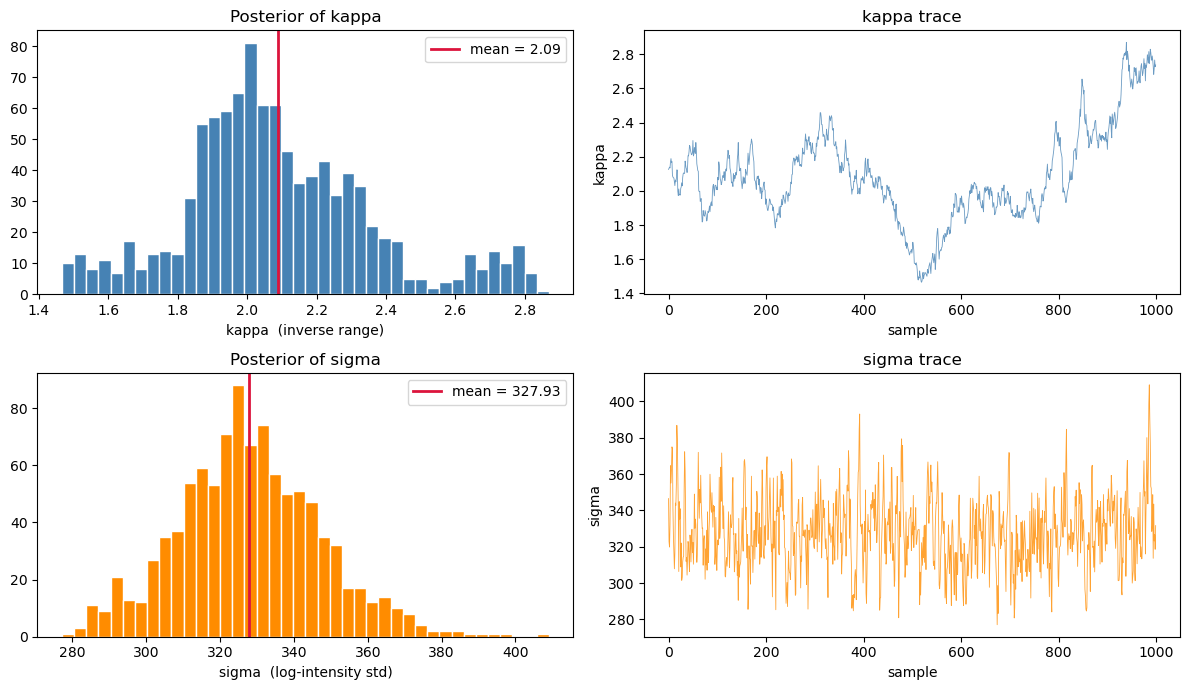

kappa  mean=2.087  std=0.276
sigma  mean=327.927  std=19.424
mu     mean=10.829  std=0.038
accept rate = 0.75,  divergences = 1000


In [10]:
import numpy as np

kappas = np.exp(np.array(samples_hyper["log_kappa"]))
sigmas = np.exp(np.array(samples_hyper["log_sigma"]))
mus    = np.array(samples_hyper["mu"])

fig, axes = plt.subplots(2, 2, figsize=(12, 7))

axes[0, 0].hist(kappas, bins=40, color="steelblue", edgecolor="white")
axes[0, 0].axvline(kappas.mean(), color="crimson", lw=2, label=f"mean = {kappas.mean():.2f}")
axes[0, 0].set(xlabel="kappa  (inverse range)", title="Posterior of kappa")
axes[0, 0].legend()

axes[0, 1].plot(kappas, color="steelblue", lw=0.6, alpha=0.8)
axes[0, 1].set(xlabel="sample", ylabel="kappa", title="kappa trace")

axes[1, 0].hist(sigmas, bins=40, color="darkorange", edgecolor="white")
axes[1, 0].axvline(sigmas.mean(), color="crimson", lw=2, label=f"mean = {sigmas.mean():.2f}")
axes[1, 0].set(xlabel="sigma  (log-intensity std)", title="Posterior of sigma")
axes[1, 0].legend()

axes[1, 1].plot(sigmas, color="darkorange", lw=0.6, alpha=0.8)
axes[1, 1].set(xlabel="sample", ylabel="sigma", title="sigma trace")

plt.tight_layout()
plt.show()

print(f"kappa  mean={kappas.mean():.3f}  std={kappas.std():.3f}")
print(f"sigma  mean={sigmas.mean():.3f}  std={sigmas.std():.3f}")
print(f"mu     mean={mus.mean():.3f}  std={mus.std():.3f}")
print(f"accept rate = {float(info_hyper.acceptance_rate.mean()):.2f},  divergences = {int(info_hyper.is_divergent.sum())}")


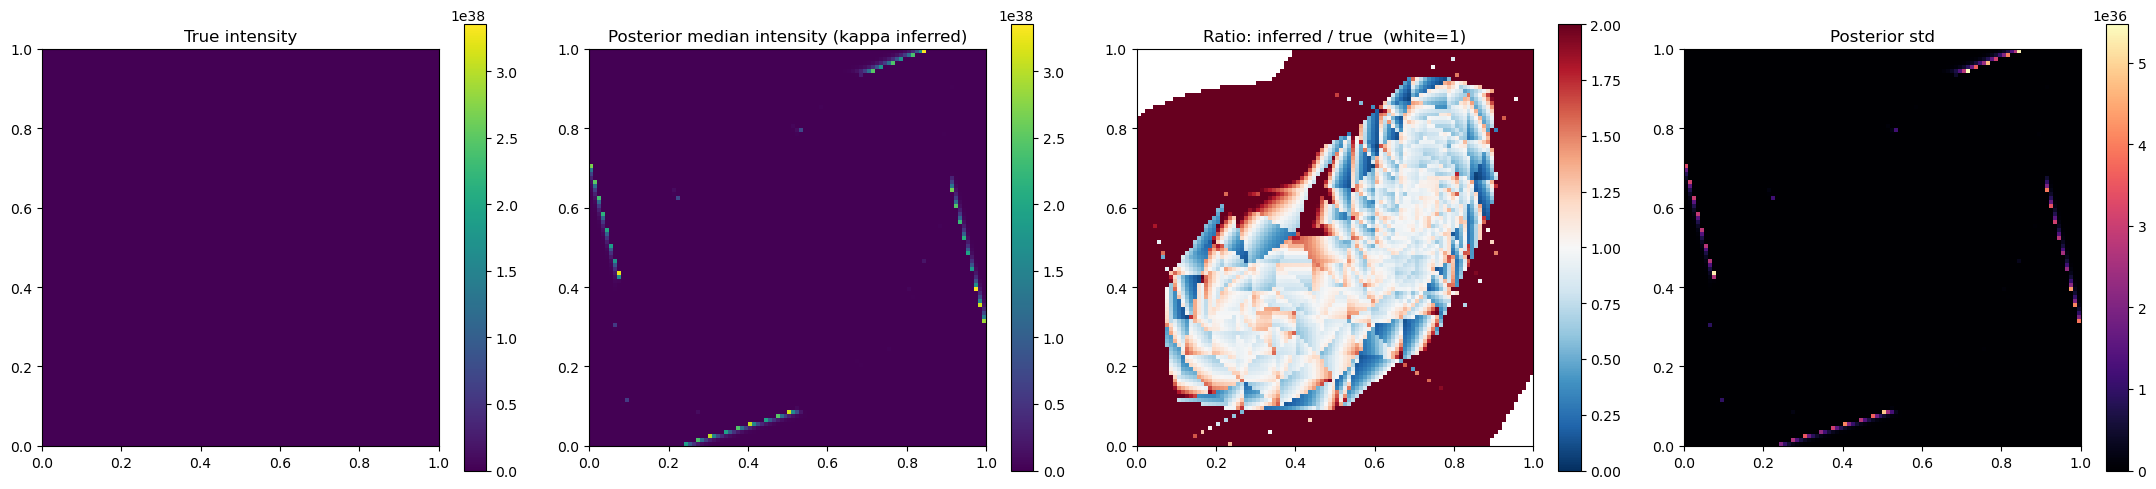

In [11]:
grid_1d = np.linspace(0, 1, 100)
gx, gy  = np.meshgrid(grid_1d, grid_1d)
grid    = np.column_stack([gx.ravel(), gy.ravel()])

lam_h           = predict_intensity(samples_hyper, mesh.nodes, mesh.triangulation, grid)
median_lam_h    = np.median(lam_h, axis=0)
std_lam_h       = np.std(lam_h, axis=0)
median_lam_2d_h = median_lam_h.reshape(100, 100)
std_lam_2d_h    = std_lam_h.reshape(100, 100)

true_lam_2d = (mixture_density(grid, components) * meta_hyper["n_obs"]).reshape(100, 100)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
kw = dict(origin="lower", extent=[0, 1, 0, 1], aspect="equal")
vmax = max(true_lam_2d.max(), median_lam_2d_h.max())

im0 = axes[0].imshow(true_lam_2d,     cmap="viridis", vmin=0, vmax=vmax, **kw)
axes[0].set_title("True intensity")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(median_lam_2d_h, cmap="viridis", vmin=0, vmax=vmax, **kw)
axes[1].set_title("Posterior median intensity (kappa inferred)")
plt.colorbar(im1, ax=axes[1])

safe_true = np.where(true_lam_2d > 1.0, true_lam_2d, np.nan)
ratio_h   = median_lam_2d_h / safe_true
im2 = axes[2].imshow(ratio_h, cmap="RdBu_r", vmin=0, vmax=2, **kw)
axes[2].set_title("Ratio: inferred / true  (white=1)")
plt.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(std_lam_2d_h, cmap="magma", **kw)
axes[3].set_title("Posterior std")
plt.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()
